# Comparación de modelos y evaluación temporal

La clase de interés es **no pago**, codificada como `0` en el dataset. Para las métricas se transforma a positivo (`True`). No se elige el modelo mirando test.

Se separan fechas en 60% entrenamiento, 20% validación y 20% prueba. Los límites respetan timestamps completos. La imputación y el encoding se ajustan exclusivamente con entrenamiento.

Se comparan una referencia de prevalencia, regresión logística, Random Forest y HistGradientBoosting. La regla de selección es mayor **average precision** (AP, resumen de la curva Precision-Recall) en validación. AP no es exactamente el área trapezoidal de esa curva.

El umbral maximiza F1 de no pago en validación. No se reajusta el modelo con validación para mantener la relación entre el modelo y el umbral. Test se reserva para medir generalización; no para elegir configuraciones.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / "Base_de_datos.csv").exists() else Path.cwd().parent
assert (ROOT / "Base_de_datos.csv").exists(), "Abrí el notebook desde el proyecto o src"


In [2]:
metadata=json.loads((ROOT/'reports/metricas.json').read_text(encoding='utf-8'))
display(pd.DataFrame(metadata['partitions']).T)
display(pd.read_csv(ROOT/'reports/comparacion_validacion.csv'))


,rows,start,end,no_payment
train,6458,2024-11-26 09:17:04,2025-04-25 17:41:12,351
validation,2152,2025-04-25 17:58:38,2025-07-12 08:34:02,91
test,2153,2025-07-12 08:51:24,2026-04-26 18:43:52,69


,modelo,roc_auc,average_precision_no_pago,precision_no_pago,recall_no_pago,f1_no_pago,prevalencia_no_pago
0,RandomForest,0.725376,0.133491,0.105556,0.208791,0.140221,0.042286
1,HistGradientBoosting,0.689914,0.106560,0.120000,0.131868,0.125654,0.042286
2,LogisticRegression,0.672894,0.083750,0.066581,0.571429,0.119266,0.042286
3,Baseline,0.500000,0.042286,0.000000,0.000000,0.000000,0.042286


## Resultado final y lectura de métricas

ROC-AUC mide ordenamiento general. AP compara la detección de no pago con la prevalencia de esa clase. Precision mide cuántas alertas son correctas; recall cuántos casos de no pago se detectan. F1 equilibra ambas sin representar costos económicos.


roc_auc                                       0.6499
average_precision_no_pago                    0.06272
precision_no_pago                           0.065099
recall_no_pago                              0.521739
f1_no_pago                                  0.115756
prevalencia_no_pago                         0.032048
matriz_confusion_no_pago     [[1567, 517], [33, 36]]
dtype: object

Elegido: RandomForest
Umbral: 0.3873766035286082


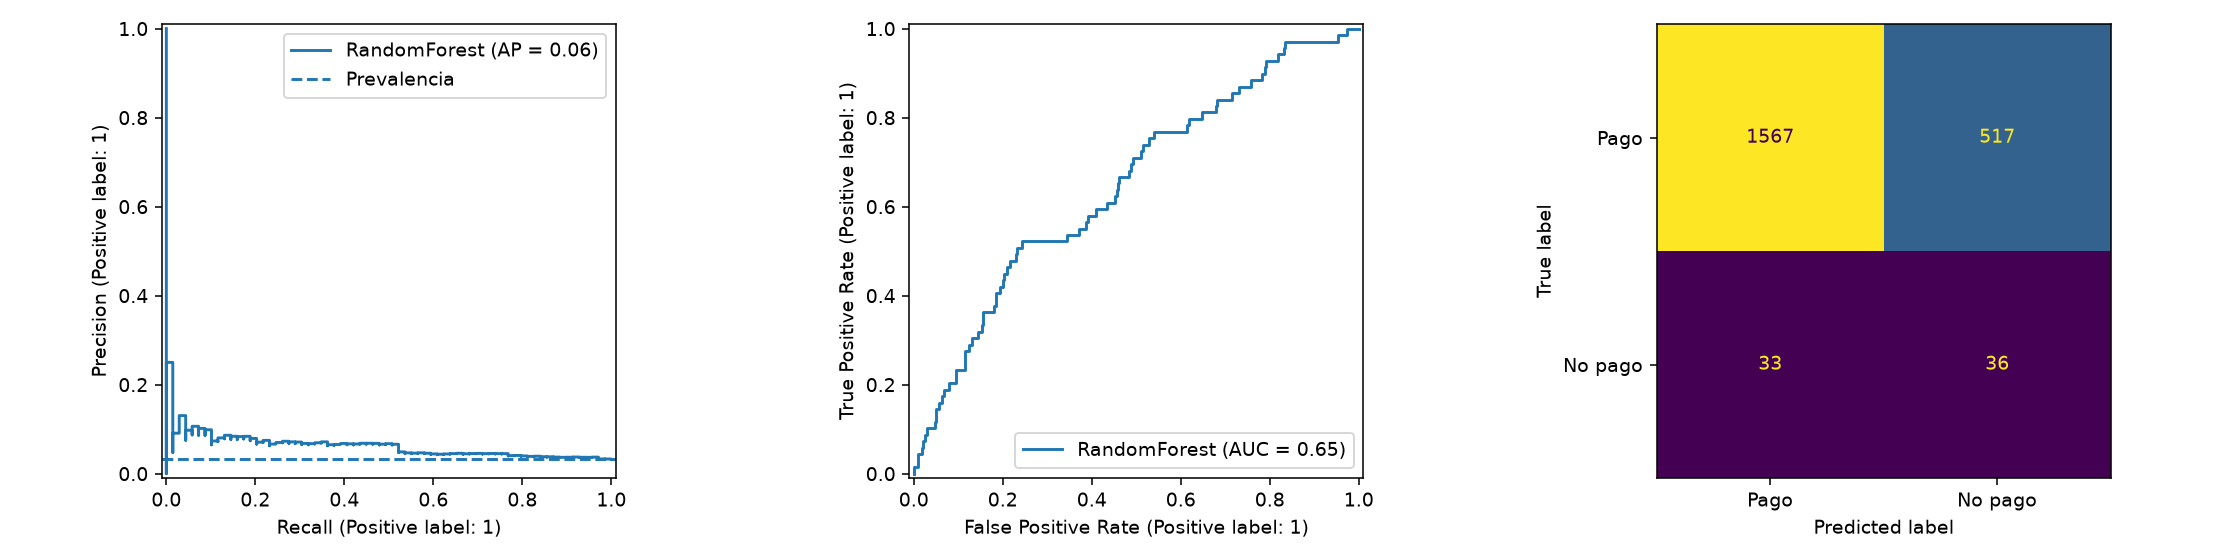

In [3]:
display(pd.Series(metadata['test']))
print('Elegido:',metadata['model_name'])
print('Umbral:',metadata['threshold_no_pago'])
display(Image(filename=str(ROOT/'reports/evaluacion_test.png')))


## Conclusión basada en la ejecución

El modelo elegido fue **RandomForest**. En test: ROC-AUC **0.650**, AP **0.063**, F1 **0.116**. La prevalencia de no pago es **3.2%**.

El umbral detecta 36 de 69 casos de no pago, pero genera 517 falsas alarmas: la precision es solo **6.5%**. El resultado supera la referencia en AP, pero no demuestra utilidad operativa suficiente. No debe presentarse como un modelo listo para decidir otorgamientos de crédito.

La prevalencia y el rendimiento cambian entre períodos. Próximos pasos: verificar disponibilidad temporal de variables, evaluar calibración y costos con datos nuevos y realizar validación temporal adicional dentro del período de desarrollo. No seguir ajustando parámetros mirando este test.

`puntaje` se excluye preventivamente por sospecha de fuga; eso no prueba que el resto de las variables estén libres de fuga. Debe confirmarse su disponibilidad al momento de la predicción.

Para regenerar estos resultados: `python src/model_training_evaluation.py`. El script guarda métricas, comparación, gráficos, modelo y hashes de datos y artefacto.


### Alcance de la independencia temporal
El EDA original explora la base completa, incluidos períodos posteriores. Aunque la selección de modelo y umbral no usa test, existe exposición exploratoria previa. Los resultados son retrospectivos; una validación externa requiere un período nuevo no examinado. No se agregaron al modelo reglas de limpieza basadas en este EDA después de observar test.